## EGE352: Data Analytic & Machine Learning

### Mini-Project: Image Classification

In this mini project, you will use Support Vector Machine to classify three types of animal: Panda, Dog and Cow.

You will do the following:

    - Download image files of panda, dog and cow.    
    - You should have 4 directories, "PandaHead_gray", "DogHead_gray and "CowHead_grey" and "proj1_test"    
    - Use "PandaHead_gray", "DogHead_gray" and "CowHead_grey" for your training and testing.
    - The images in these directories are pre-proccessed to grey scale and fixed resolution.
    - Create three list (panda, dog and cow), store the directory and file names of the images in this list. Plot two images of each animal in the notebook.    
    - Create numpy array for the images and reshape them accordingly.    
    - Re-scale the data    
    - Split the data into train set and test set    
    - Train the model using train set, use GridSearchCV to fine tune the model if required    
    - Make predictions using test set and evaluate the performance of the model    
    - Read in all images from the "proj1_test" directory, make prediction using your model on all these images   
    - Plot the images of the animal along with the prediction results using your model
    

#### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

#### Read the image files (refer to ML_Lab7a.ipynb)

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path1 ='/content/gdrive/My Drive/Data/CowHead_gray/'
files1=[]
for entry in os.listdir(path1):
    if os.path.isfile(os.path.join(path1, entry)):
        files1.append(path1+entry)
print(len(files1))

path2 ='/content/gdrive/My Drive/Data/DogHead_gray/'

files2=[]
for entry in os.listdir(path2):
    if os.path.isfile(os.path.join(path2, entry)):
        files2.append(path2+entry)
print(len(files2))

path3 ='/content/gdrive/My Drive/Data/PandaHead_gray/'

files3=[]
for entry in os.listdir(path3):
    if os.path.isfile(os.path.join(path3, entry)):
        files3.append(path3+entry)
print(len(files3))


101
133
113


#### Plot two images of each type of animal

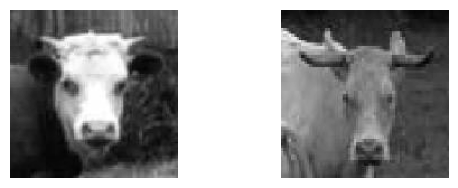

In [ ]:
for index in range(0,2):
    image=Image.open(files1[index]).convert('L')
    plt.subplot(2, 2, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray) # display the image

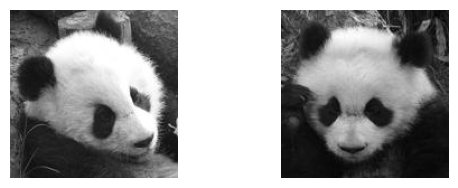

In [ ]:
for index in range(0,2):
    image=Image.open(files3[index]).convert('L')
    plt.subplot(2, 2, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray) # display the image

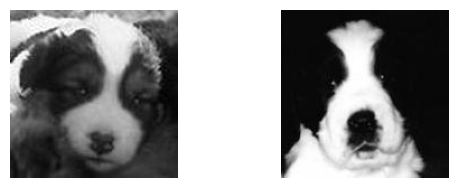

In [ ]:
for index in range(0,2):
    image=Image.open(files2[index]).convert('L')
    plt.subplot(2, 2, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray) # display the image

#### Create numpy array for the images; reshape and rescale them accordingly

In [ ]:
target=[]
vector=[]

for i in [files1,files2,files3]:
  for file_name in i:
    img = Image.open(file_name).convert('L')
    arr = np.array(img)
    vector.append(arr)

    if i==files1:
      target.append('cow')

    if i==files2:
      target.append('dog')

    if i==files3:
      target.append('panda')

vectors=np.array(vector).reshape(-1,150,150)
targets=np.array(target)

print(len(vectors))
print(len(targets))

347
347


#### Split the data into train set and test set

In [ ]:
from sklearn.model_selection import train_test_split

X=vectors.reshape(-1,150*150)
X=X/255
y=target

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.30,
                                                    random_state=101
                                                    )

### Train model using SVM

#### Choose a Support Vector Machine classifier

In [ ]:
from sklearn import svm, metrics
C = 1  # SVM regularization parameter
model = svm.SVC(kernel='rbf', gamma=0.01, C=C)

#### Train the model

In [ ]:
model.fit(X_train, y_train)

SVC(C=1, gamma=0.01)

#### Make prediction using the test set

In [ ]:
pred_test = model.predict(X_test)

#### Evaluate the model performance using confusion matrix and classification report¶

In [ ]:
print("Confusion matrix:\n%s" % metrics.confusion_matrix(y_test, pred_test,labels=['panda','dog','cow']))
print("\n accuracy: ", model.score(X_test, y_test))
# below is alternative way to calculate accuracy score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,pred_test)
print(accuracy)

Confusion matrix:
[[ 0 34  0]
 [ 0 40  0]
 [ 0 31  0]]

 accuracy:  0.38095238095238093
0.38095238095238093


#### Use GridSearchCV to fine tune your model parameters

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1,1, 10, 100, 1000], 'gamma': [1,0.1,0.01,0.001,0.0001]}
model = svm.SVC(kernel='rbf')
grid = GridSearchCV(model,param_grid,refit=True,verbose=5).fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ....................C=0.1, gamma=1;, score=0.388 total time=   0.9s
[CV 2/5] END ....................C=0.1, gamma=1;, score=0.388 total time=   0.9s
[CV 3/5] END ....................C=0.1, gamma=1;, score=0.396 total time=   1.0s
[CV 4/5] END ....................C=0.1, gamma=1;, score=0.375 total time=   0.9s
[CV 5/5] END ....................C=0.1, gamma=1;, score=0.375 total time=   1.6s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.388 total time=   2.0s
[CV 2/5] END ..................C=0.1, gamma=0.1;, score=0.388 total time=   1.5s
[CV 3/5] END ..................C=0.1, gamma=0.1;, score=0.396 total time=   0.9s
[CV 4/5] END ..................C=0.1, gamma=0.1;, score=0.375 total time=   0.9s
[CV 5/5] END ..................C=0.1, gamma=0.1;, score=0.375 total time=   0.9s
[CV 1/5] END .................C=0.1, gamma=0.01;, score=0.388 total time=   0.9s
[CV 2/5] END .................C=0.1, gamma=0.01

#### Train/assign the model using the best parameters

In [ ]:
grid.best_params_
classifier = grid.best_estimator_
classifier

SVC(C=10, gamma=0.0001)

In [ ]:
pred_test = classifier.predict(X_test)

#### Evaluate the model performance using confusion matrix and classification report¶

In [ ]:
print("Confusion matrix:\n%s" % metrics.confusion_matrix(y_test, pred_test,labels=['panda','dog','cow']))
print("\n accuracy: ", classifier.score(X_test, y_test))

Confusion matrix:
[[32  0  2]
 [ 0 34  6]
 [ 1  8 22]]

 accuracy:  0.8380952380952381


### Test the trained model using new test data

#### Read in all images from the 'proj1_test/' directory, predict the animal using the trained model.

Mounted at /content/gdrive


array(['cow'], dtype='<U5')

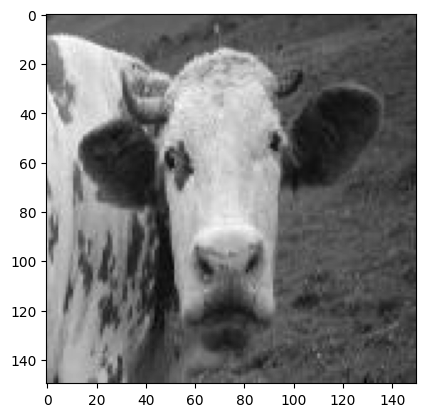

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive',force_remount=True)
from PIL import Image
import os
img = Image.open('/content/gdrive/MyDrive/Data/proj1_test/cattlefrontal0053.jpg')
arr1 = np.array(img)
arr1=arr1/255
plt.imshow(arr1, cmap=plt.cm.gray)
classifier.predict(arr1.reshape(-1,150*150))

array(['cow'], dtype='<U5')

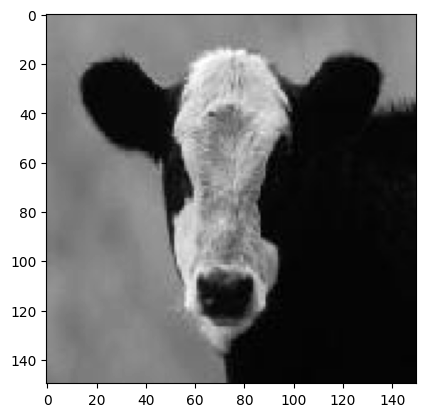

In [ ]:
img2 = Image.open('/content/gdrive/MyDrive/Data/proj1_test/cattlefrontal0089.jpg')
arr2 = np.array(img2)
arr2=arr2/255
plt.imshow(arr2, cmap=plt.cm.gray)
classifier.predict(arr2.reshape(-1,150*150))

array(['dog'], dtype='<U5')

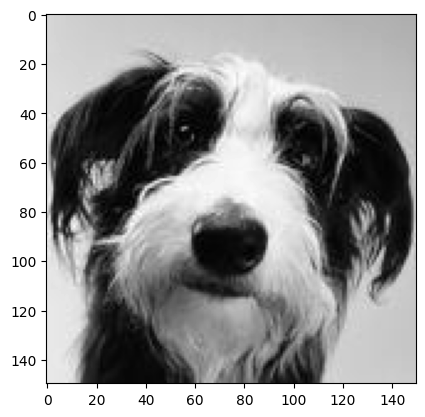

In [ ]:
img3 = Image.open('/content/gdrive/MyDrive/Data/proj1_test/dog000253a.jpg')
arr3 = np.array(img3)
arr3=arr3/255
plt.imshow(arr3, cmap=plt.cm.gray)
classifier.predict(arr3.reshape(-1,150*150))

array(['dog'], dtype='<U5')

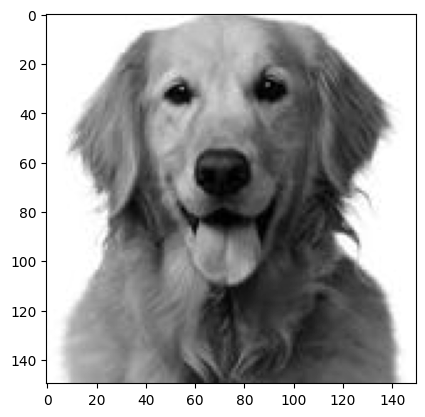

In [ ]:
img4 = Image.open('/content/gdrive/MyDrive/Data/proj1_test/dog000916a.jpg')
arr4 = np.array(img4)
arr4=arr4/255
plt.imshow(arr4, cmap=plt.cm.gray)
classifier.predict(arr4.reshape(-1,150*150))

array(['panda'], dtype='<U5')

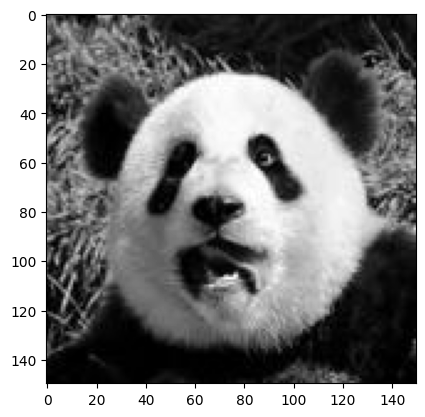

In [ ]:
img5 = Image.open('/content/gdrive/MyDrive/Data/proj1_test/pandafrontal0023.jpg')
arr5 = np.array(img5)
arr5=arr5/255
plt.imshow(arr5, cmap=plt.cm.gray)
classifier.predict(arr5.reshape(-1,150*150))

array(['panda'], dtype='<U5')

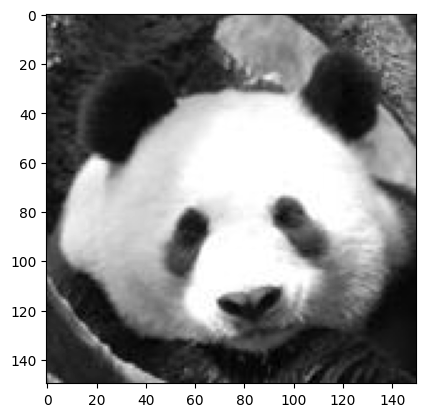

In [ ]:
img6 = Image.open('/content/gdrive/MyDrive/Data/proj1_test/pandafrontal0028.jpg')
arr6 = np.array(img6)
arr6=arr6/255
plt.imshow(arr6, cmap=plt.cm.gray)
classifier.predict(arr6.reshape(-1,150*150))

#### Plot the images of the animal along with the prediction results


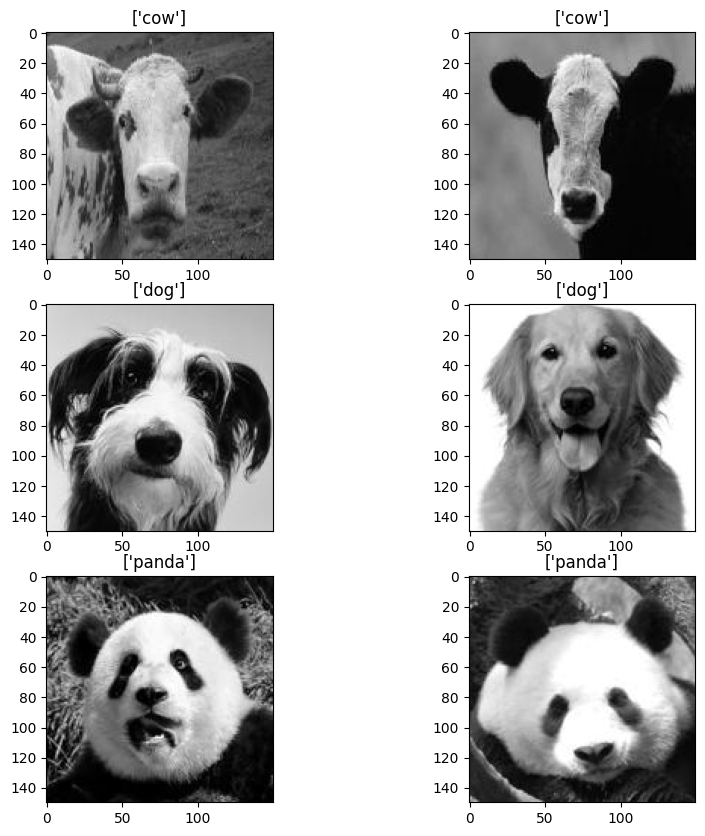

In [ ]:
# prompt: Plot the images of the animal along with the prediction results

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes[0, 0].imshow(arr1, cmap=plt.cm.gray)
axes[0, 0].set_title(classifier.predict(arr1.reshape(-1, 150 * 150)))
axes[0, 1].imshow(arr2, cmap=plt.cm.gray)
axes[0, 1].set_title(classifier.predict(arr2.reshape(-1, 150 * 150)))
axes[1, 0].imshow(arr3, cmap=plt.cm.gray)
axes[1, 0].set_title(classifier.predict(arr3.reshape(-1, 150 * 150)))
axes[1, 1].imshow(arr4, cmap=plt.cm.gray)
axes[1, 1].set_title(classifier.predict(arr4.reshape(-1, 150 * 150)))
axes[2, 0].imshow(arr5, cmap=plt.cm.gray)
axes[2, 0].set_title(classifier.predict(arr5.reshape(-1, 150 * 150)))
axes[2, 1].imshow(arr6, cmap=plt.cm.gray)
axes[2, 1].set_title(classifier.predict(arr6.reshape(-1, 150 * 150)))
plt.show()


### Demo your project to your. Explain how you can how you can applied what you have learnt in machine learning in daily life.

# Well Done! You have completed the module on "Data Analytics and Machine Learning"